In [37]:
import fsspec
import s3fs
import os
import ujson
from pathlib import Path
import xarray as xr
import cf_xarray
import numpy as np
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy

In [38]:
fs = fsspec.filesystem(
    "reference", 
    fo='all.json', 
    remote_protocol="s3", 
    remote_options={"anon":True},
    skip_instance_cache=True
)
m = fs.get_mapper("")
dk = xr.open_dataset(m, engine='zarr', consolidated=False)
dk

<xarray.Dataset> Size: 38GB
Dimensions:   (init: 30, lat: 844, lead: 12, lon: 774, member: 10)
Coordinates:
  * init      (init) datetime64[ns] 240B 1993-03-01 1994-03-01 ... 2022-03-01
  * lat       (lat) float64 7kB 5.273 5.335 5.398 5.461 ... 58.04 58.1 58.16
  * lead      (lead) int32 48B 0 1 2 3 4 5 6 7 8 9 10 11
  * lon       (lon) float64 6kB 261.6 261.6 261.7 261.8 ... 323.8 323.8 323.9
  * member    (member) int32 40B 1 2 3 4 5 6 7 8 9 10
    month     (init) float64 240B ...
Data variables:
    tob       (init, member, lead, lat, lon) float32 9GB ...
    tob_anom  (init, member, lead, lat, lon) float32 9GB ...
    tos       (init, member, lead, lat, lon) float32 9GB ...
    tos_anom  (init, member, lead, lat, lon) float32 9GB ...
Attributes: (12/29)
    NCO:                    netCDF Operators version 5.1.5 (Homepage = http:/...
    NumFilesInSet:          1
    cefi_archive_version:   /archive/acr/fre/NWA/2023_04/NWA12_forecast_2023-...
    cefi_aux:               archive format yyyy-mm-e## represents the initial...
    cefi_data_doi:          10.5281/zenodo.10642295
    cefi_date_range:        N/A
    ...                     ...
    data_reference:         https://doi.org/10.5281/zenodo.10642294
    dataset:                regional mom6 regrid
    grid_tile:              N/A
    grid_type:              regular
    paper_reference:        https://doi.org/10.5194/egusphere-2024-394
    title:                  NWA12_forecast_2023-04_1994-03-e01

In [39]:
xmin = dk.cf['longitude'].min().item()
xmax = dk.cf['longitude'].max().item()
ymin = dk.cf['latitude'].min().item()
ymax = dk.cf['latitude'].max().item()
xmin, xmax, ymin, ymax

(261.5577392578125, 323.9200134277344, 5.272542476654053, 58.1607551574707)

In [43]:
slice=dk['tos'].sel(init='1999-03-01', lead=4, member=9, method='nearest')
slice

<xarray.DataArray 'tos' (lat: 844, lon: 774)> Size: 3MB
[653256 values with dtype=float32]
Coordinates:
    init     datetime64[ns] 8B 1999-03-01
  * lat      (lat) float64 7kB 5.273 5.335 5.398 5.461 ... 58.04 58.1 58.16
    lead     int32 4B 4
  * lon      (lon) float64 6kB 261.6 261.6 261.7 261.8 ... 323.8 323.8 323.9
    member   int32 4B 9
    month    float64 8B 12.0
Attributes:
    cell_methods:   area:mean yh:mean xh:mean time: mean
    long_name:      Sea Surface Temperature
    standard_name:  sea_surface_temperature
    time_avg_info:  average_T1,average_T2,average_DT
    units:          degC

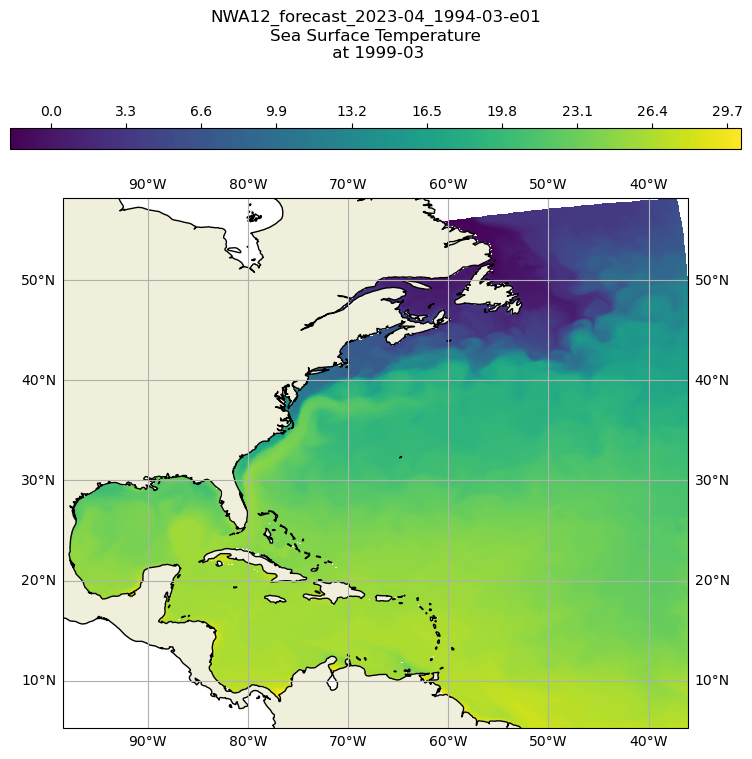

In [44]:
title_date='1999-03'
aspect = (xmax - xmin)/(ymax-ymin)
plt.figure(figsize=(8*aspect,8))
proj = ccrs.PlateCarree(central_longitude=180)
proj180 = ccrs.PlateCarree()
ax = plt.axes(projection=proj)
ax.set_extent([xmin, xmax, ymin, ymax], crs=proj180)
# add some features to make the map a little more polished
ax.add_feature(cartopy.feature.LAND)
# ax.add_feature(cartopy.feature.OCEAN)
ax.coastlines('50m')
gl = ax.gridlines(draw_labels=True)
ct = ax.contourf(dk.cf['longitude'], dk.cf['latitude'], slice, levels=255, transform=proj180)
plt.colorbar(ct, orientation='horizontal',pad=0.08, aspect=35, fraction=.06, location='top')
plt.title(dk.attrs['title'] + '\n' + slice.attrs['long_name'] + '\n at ' + title_date , y=1.25)
plt.show()